In [131]:
import math
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon, Circle
import numpy as np


def triangular_lattice_positions(Lx, Ly):
    pos = {}
    for i in range(Lx):
        for j in range(Ly):
            x = i + 0.5 * j
            y = (math.sqrt(3) / 2.0) * j
            pos[(i, j)] = (x, y)
    return pos

def triangular_spin_graph(Lx, Ly):
    G = nx.Graph()
    for i in range(Lx):
        for j in range(Ly):
            G.add_node((i, j))

    # triangular-lattice nearest neighbors
    for i in range(Lx):
        for j in range(Ly):
            for di, dj in [(1, 0), (0, 1), (1, -1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < Lx and 0 <= nj < Ly:
                    G.add_edge((i, j), (ni, nj))
    return G

def nm_check_vertices(i, j):
    # Newman-Moore right-pointing check
    return [(i, j), (i + 1, j), (i , j + 1)]

def draw_triangle_center_circles(
    ax,
    pos,
    triangle_circle_colors,
    radius=0.11,
    alpha=0.95,
    edgecolor="none",
    linewidth=1.0,
    zorder=11,
):
    """
    Draw colored circles at the centers of Newman-Moore triangles.

    Parameters
    ----------
    ax : matplotlib axis
    pos : dict
        Spin-site positions, keyed by (i,j).
    triangle_circle_colors : dict
        Dictionary {(i,j): color}, where (i,j) labels the triangle/check.
    radius : float
        Circle radius in data coordinates.
    """
    for (i, j), color in triangle_circle_colors.items():
        cx, cy = triangle_centroid(i, j, pos)
        circ = Circle(
            (cx, cy),
            radius=radius,
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(circ)

def triangle_centroid(i, j, pos):
    verts = nm_check_vertices(i, j)
    cx = sum(pos[v][0] for v in verts) / 3.0
    cy = sum(pos[v][1] for v in verts) / 3.0
    return np.array([cx, cy], dtype=float)

def draw_spin_crosses(
    ax,
    pos,
    spin_cross_sites,
    color="purple",
    size=180,
    linewidth=2.2,
    zorder=20,
):
    xs = [pos[v][0] for v in spin_cross_sites if v in pos]
    ys = [pos[v][1] for v in spin_cross_sites if v in pos]

    ax.scatter(
        xs,
        ys,
        marker="x",
        s=size,
        c=color,
        linewidths=linewidth,
        zorder=zorder,
    )

def draw_triangle_text_values(
    ax,
    pos,
    triangle_text_values,
    fontsize=10,
    text_color="brown",
    use_bbox=True,
    bbox_fc="white",
    bbox_alpha=0.59,
    zorder=15,
):
    """
    triangle_text_values: dict {(i,j): value}
    Places text at the centroid of chosen triangles only.
    """
    for (i, j), val in triangle_text_values.items():
        cx, cy = triangle_centroid(i, j, pos)

        kwargs = dict(
            ha="center",
            va="center",
            fontsize=fontsize,
            color=text_color,
            zorder=zorder,
        )

        if use_bbox:
            kwargs["bbox"] = dict(
                boxstyle="round,pad=0.12",
                fc=bbox_fc,
                ec="none",
                alpha=bbox_alpha,
            )

        ax.text(cx, cy, str(val), **kwargs)

def draw_nm(
    Lx=6,
    Ly=5,
    error_qubits=None,
    violated_checks=None,
    triangle_center_circles=None,
    spin_cross_sites=None,
    cross_color="purple",
    cross_size=180,
    cross_linewidth=2.2,
    triangle_text_values=None,
    label=False,
):
    if error_qubits is None:
        error_qubits = set()
    if violated_checks is None:
        violated_checks = set()

    G = triangular_spin_graph(Lx, Ly)
    pos = triangular_lattice_positions(Lx, Ly)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    # base lattice
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.2, alpha=0.45)

    # all qubits as light circles
    all_nodes = list(G.nodes)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=all_nodes,
        ax=ax,
        node_size=80,
        node_color="white",
        edgecolors="black",
        linewidths=1.0,
    )
    # normalize and prepare optional parameters
    if triangle_center_circles is None:
        triangle_center_circles = {}
    else:
        triangle_center_circles = dict(triangle_center_circles)

    if triangle_text_values is None:
        triangle_text_values = {}
    else:
        triangle_text_values = dict(triangle_text_values)
    
    if spin_cross_sites is None:
        spin_cross_sites = set()
    else:
        spin_cross_sites = set(spin_cross_sites)

    # violated stabilizers as shaded triangles
    for (i, j) in violated_checks:
        verts = nm_check_vertices(i, j)
        if all(v in pos for v in verts):
            poly_xy = [pos[v] for v in verts]
            patch = Polygon(
                poly_xy,
                closed=True,
                facecolor="black",
                edgecolor="black",
                alpha=0.18,
                linewidth=2.0,
                zorder=2,
            )
            ax.add_patch(patch)

    # qubit errors as shaded dots
    if error_qubits:
        err_xy = [pos[v] for v in error_qubits if v in pos]
        ax.scatter(
            [p[0] for p in err_xy],
            [p[1] for p in err_xy],
            s=80,              # slightly larger than base node
            c="gray",
            alpha=0.4,         # shading
            linewidths=0,
            zorder=3,
        )
        ax.scatter(
            [p[0] for p in err_xy],
            [p[1] for p in err_xy],
            s=80,              # redraw crisp boundary
            facecolors="none",
            edgecolors="black",
            linewidths=1.6,
            zorder=4,
        )

    # redraw qubit centers so nodes stay crisp over triangle fills
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=all_nodes,
        ax=ax,
        node_size=80,
        node_color="white",
        edgecolors="black",
        linewidths=1.0,
    )

    # then redraw the error dots once more on top
    if error_qubits:
        ax.scatter(
            [pos[v][0] for v in error_qubits if v in pos],
            [pos[v][1] for v in error_qubits if v in pos],
            s=80,
            c="black",
            alpha=0.45,
            linewidths=0,
            zorder=5,
        )
    # draw crosses on chosen sites
    if spin_cross_sites:
        draw_spin_crosses(
            ax=ax,
            pos=pos,
            spin_cross_sites=spin_cross_sites,
            color=cross_color,
            size=cross_size,
            linewidth=cross_linewidth,
            zorder=20,
        )
    
    if triangle_text_values:
        draw_triangle_text_values(
            ax=ax,
            pos=pos,
            triangle_text_values=triangle_text_values,
            fontsize=10,
    )
        # tag spins with indices 
        # nx.draw_networkx_labels(
        #     G,
        #     pos,    
        #     labels={v: str(k) for k, v in enumerate(error_qubits, start=1)},
        #     font_size=10,
        #     ax=ax,
        #     font_color='blue'
        # )   

    if label:
        nx.draw_networkx_labels(
            G, pos, ax=ax,
            labels={v: f"{v}" for v in G.nodes},
            font_size=8
        )


    # color circle triangles     
    if triangle_center_circles:
        draw_triangle_center_circles(
            ax=ax,
            pos=pos,
            triangle_circle_colors=triangle_center_circles,
            radius=0.21,
            alpha=0.95,
            edgecolor="white",
            linewidth=0.8,
            zorder=12,
        )
    ax.set_aspect("equal")
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_checkerboard(q, ax=None, title=None):
    """
    Checkerboard-style plot for a 2D binary array q (values 0/1).
    Uses a 2-color discrete colormap + crisp square pixels.
    """
    q = np.asarray(q)
    if q.ndim != 2:
        raise ValueError("q must be 2D")
    if ax is None:
        fig, ax = plt.subplots()

    cmap = ListedColormap(["white", "black"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    im = ax.imshow(q, origin="upper", interpolation="nearest", cmap=cmap, norm=norm)
    ax.set_xticks([])
    ax.set_yticks([])
    if title:
        ax.set_title(title)
    return ax, im





In [25]:

def bit_array_to_sites(arr, swap_rc_to_ij=True):
    """
    Convert a 2D 0/1 array into a set of lattice sites.

    Parameters
    ----------
    arr : array-like, shape (nrows, ncols)
        Binary array with 1 marking an occupied/error site.
    swap_rc_to_ij : bool
        If True, interpret arr[row, col] as lattice site (col, row).
        If False, interpret arr[i, j] directly as site (i, j).

    Returns
    -------
    sites : set of tuple[int, int]
        Set of lattice coordinates.
    """
    arr = np.asarray(arr)
    coords = np.argwhere(arr == 1)   # each entry is [row, col]

    if swap_rc_to_ij:
        return {(int(c), int(r)) for r, c in coords}
    else:
        return {(int(r), int(c)) for r, c in coords}
    
def pascal_mod2_rows(num_rows: int, width: int | None = None) -> np.ndarray:
    """
    Build rows of (1+x)^n over GF(2).

    Output A has shape (num_rows, width), where
    A[n, k] = 1 iff coeff of x^k in (1+x)^n is 1 mod 2.
    """
    if width is None:
        width = num_rows

    A = np.zeros((num_rows, width), dtype=np.uint8)
    A[0, 0] = 1   # (1+x)^0 = 1

    for n in range(num_rows - 1):
        row = A[n]
        shifted = np.zeros_like(row)
        shifted[1:] = row[:-1]          # x * row
        A[n + 1] = row ^ shifted        # mod-2 addition

    return A

In [26]:
from benchmark import *

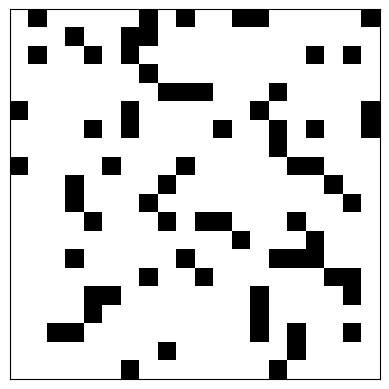

In [3]:
H, L = 20, 20
random.seed(42)
np.random.seed(42)
error_rate = 0.2
p_dyn = 0.0000001
lattice = np.zeros((H, L), dtype=int)
lattice = monte_carlo_error(lattice, error_rate= error_rate, num_steps=1)
plot_checkerboard(lattice)
random.seed(43)
np.random.seed(43)
# lattice = bkl(lattice, error_rate= p_dyn, steps=2000)[0]



In [4]:
H, L = s, s
random.seed(42)
np.random.seed(42)
error_rate = 0.2
p_dyn = 0.001
lattice = np.zeros((H, L), dtype=int)
# lattice = monte_carlo_error(lattice, error_rate= error_rate, num_steps=1)
lattice = bkl(lattice, error_rate= p_dyn, steps=2000)
plot_checkerboard(lattice)




NameError: name 's' is not defined

(<Axes: >, <matplotlib.image.AxesImage at 0x19790c410>)

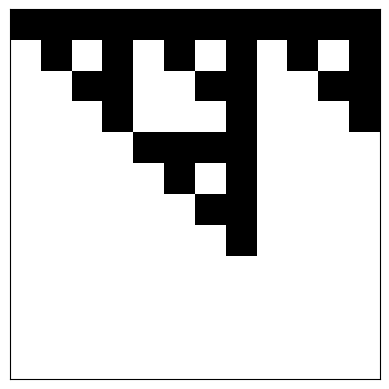

In [43]:
lat = np.roll(lattice, 1,0)
plot_checkerboard(lat)

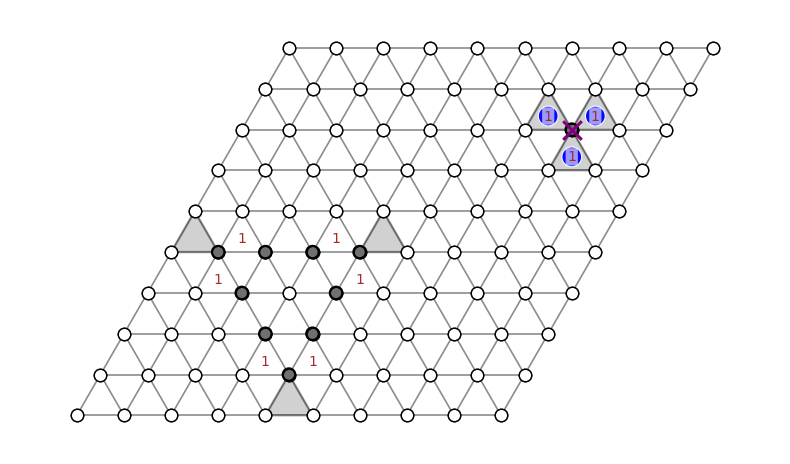

In [133]:
# example
# error_qubits = {(1, 0), (2, 0), (0, 1), (2, 1), (3, 1), (0, 2), (1, 2), (3, 2), (1, 3), (2, 3), }
s = 4
lat = pascal_mod2_rows(s, s)
lat = np.transpose(lat)
# lat = lat[::-1]
lat = np.pad(lat, ((1, 1)), mode='constant', constant_values=0)
error_qubits = bit_array_to_sites(lat[::-1], swap_rc_to_ij=True)
error_qubits.add((2*s-1, 2*s-1))
violated_checks = {(s, 0), (s,s), (0,s), (2*s-1, 2*s-1), (2*s-2, 2*s-1), (2*s-1, 2*s-2)}

# logicals plot
# lat = np.zeros((s, s))
# logicals = logical_operators(lat)

# lat = np.roll(lattice, 1,0)
# lat = np.pad(lat, ((1, 1)), mode='constant', constant_values=0)
# error_qubits = bit_array_to_sites(lat[::-1], swap_rc_to_ij=True)
# violated_checks = {(0,12), (12, 8), (12, 12), (8,4)}


#custom example
# error_qubits = {(1,1), (2, 1), (3,3)}
# violated_checks = {(1,0), (2,0), (0,1), (2,1), (2, 3), (3, 3), (3,2)}

triangle_center_circles = {
    # (s, 0): 'blue',
    # (s, s): 'blue',
    # (0, s): 'blue',
    # (s//2, s//2): 'red',
    # (s//2, s): 'red',
    # (s, s//2): 'red',
    (2*s-1, 2*s-1): 'blue', 
    (2*s-2, 2*s-1): 'blue', 
    (2*s-1, 2*s-2): 'blue'
}
spin_crosses = {
    (2*s-1, 2*s-1)
    # (1,s), (s,1), (s,s), (s//2, s), (s//2 + 1, s), (s, s//2), (s, s//2 + 1), (s//2, s//2 + 1), (s//2 +1, s//2)
    }
    
triangle_text_values ={
    (s-1, 1): '1', 
    (s, 1): '1',
    (s-1,s): '1', 
    (s,s-1): '1', 
    (1,s): '1', 
    (1,s-1): '1',
    (2*s-1, 2*s-1): '1', 
    (2*s-2, 2*s-1): '1', 
    (2*s-1, 2*s-2): '1'
}

fig, ax = draw_nm(
    Lx=2*s+2,
    Ly=2*s+2,
    error_qubits=error_qubits,
    violated_checks=violated_checks,
    triangle_center_circles=triangle_center_circles,
    spin_cross_sites=spin_crosses,
    triangle_text_values = triangle_text_values,
    label=False,
)
plt.show()

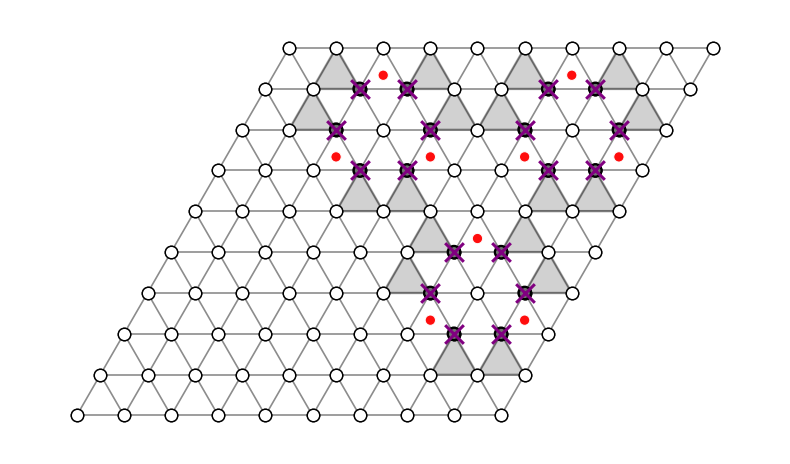

In [98]:
error_qubits_1 = error_qubits.copy()
spin_crosses = {(1,s), (s,1), (s,s), (s//2, s), (s//2 + 1, s), (s, s//2), (s, s//2 + 1), (s//2, s//2 + 1), (s//2 +1, s//2)}

for x in spin_crosses:
    error_qubits_1.remove(x)

violated_checks = {
    (1, s-1), (4, s-1), (1, s), (s-1, 1), (s, 1), (3, s), (5, s), (s-1, s), (s, s-1), (s-3, s-1), (s-1, s-3), (s, s-3), (3, 5), (4, 5), (5,4), (7,4), (5,3), (8,3)
}

triangle_center_circles = {
    # (s-1, 1): 'blue',
    # (s, 1): 'blue',
    # (s, s-1): 'blue',
    # (s-1, s): 'blue',
    # (1, s): 'blue',
    # (1, s-1): 'blue',
    
    (2, s): 'red',
    (2, s-2): 'red',
    (4, s-2): 'red',
    (s-2, 2): 'red',
    (s-2, 4): 'red',
    (s, 2): 'red',
    (s, s-2): 'red',
    (s-2, s): 'red',
    (s-2, s-2): 'red',
}
spin_crosses = {
    (s-1, 2), (s, 2), (s-2, 3), (s, 3), (s-2, 4), (s-1, 4), (s-1, s-2), (s, s-2), (s-2, s-1), (s, s-1), (s-2, s), (s-1, s), (2, s), (3, s), (2, s-1), (4, s-1), (3, s-2), (4, s-2),
    # (1, s), (s, s), (s, 1)
    }
    
fig, ax = draw_nm(
    Lx=s+2,
    Ly=s+2,
    error_qubits=error_qubits_1,
    violated_checks=violated_checks,
    triangle_center_circles=triangle_center_circles,
    spin_cross_sites=spin_crosses,
    label=False,
)
plt.show()

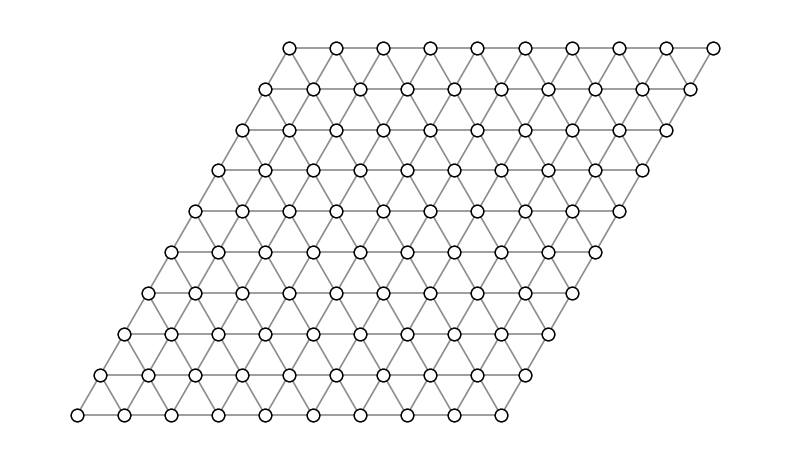

In [100]:
error_qubits_2 = {}

violated_checks = {
}

triangle_center_circles = {
    # (s-1, 1): 'blue',
    # (s, 1): 'blue',
    # (s, s-1): 'blue',
    # (s-1, s): 'blue',
    # (1, s): 'blue',
    # (1, s-1): 'blue',
    
    # (2, s): 'red',
    # (2, s-2): 'red',
    # (4, s-2): 'red',
    # (s-2, 2): 'red',
    # (s-2, 4): 'red',
    # (s, 2): 'red',
    # (s, s-2): 'red',
    # (s-2, s): 'red',
    # (s-2, s-2): 'red',
}
spin_crosses = {
    # (s-1, 2), (s, 2), (s-2, 3), (s, 3), (s-2, 4), (s-1, 4), (s-1, s-2), (s, s-2), (s-2, s-1), (s, s-1), (s-2, s), (s-1, s), (2, s), (3, s), (2, s-1), (4, s-1), (3, s-2), (4, s-2),
    # (1, s), (s, s), (s, 1)
    }
    
fig, ax = draw_nm(
    Lx=s+2,
    Ly=s+2,
    error_qubits=error_qubits_2,
    violated_checks=violated_checks,
    triangle_center_circles=triangle_center_circles,
    spin_cross_sites=spin_crosses,
    label=False,
)
plt.show()

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import Polygon, FancyArrowPatch, Circle

# ------------------------------------------------------------
# Triangular spin lattice
# ------------------------------------------------------------
def triangular_lattice_positions(Lx, Ly):
    """
    Spin positions for a triangular lattice.
    Node labels are (i, j).
    """
    h = math.sqrt(3) / 2.0
    return {(i, j): (i + 0.5 * j, h * j) for i in range(Lx) for j in range(Ly)}

def triangular_spin_graph(Lx, Ly):
    """
    Undirected triangular-lattice nearest-neighbor graph.
    """
    G = nx.Graph()
    for i in range(Lx):
        for j in range(Ly):
            G.add_node((i, j))

    for i in range(Lx):
        for j in range(Ly):
            for di, dj in [(1, 0), (0, 1), (1, -1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < Lx and 0 <= nj < Ly:
                    G.add_edge((i, j), (ni, nj))
    return G

def draw_triangle_center_circles(
    ax,
    pos,
    triangle_circle_colors,
    radius=0.11,
    alpha=0.95,
    edgecolor="none",
    linewidth=1.0,
    zorder=11,
):
    """
    Draw colored circles at the centers of Newman-Moore triangles.

    Parameters
    ----------
    ax : matplotlib axis
    pos : dict
        Spin-site positions, keyed by (i,j).
    triangle_circle_colors : dict
        Dictionary {(i,j): color}, where (i,j) labels the triangle/check.
    radius : float
        Circle radius in data coordinates.
    """
    for (i, j), color in triangle_circle_colors.items():
        cx, cy = triangle_centroid(i, j, pos)
        circ = Circle(
            (cx, cy),
            radius=radius,
            facecolor=color,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            zorder=zorder,
        )
        ax.add_patch(circ)
# ------------------------------------------------------------
# Newman-Moore right-pointing checks
# S(i,j) uses vertices (i,j), (i+1,j), (i+1,j+1)
# ------------------------------------------------------------
def nm_check_vertices(i, j):
    return [(i, j), (i + 1, j), (i , j + 1)]

def triangle_centroid(i, j, pos):
    verts = nm_check_vertices(i, j)
    cx = sum(pos[v][0] for v in verts) / 3.0
    cy = sum(pos[v][1] for v in verts) / 3.0
    return np.array([cx, cy], dtype=float)

# ------------------------------------------------------------
# Helpers for triangle values
# ------------------------------------------------------------
def triangle_values_from_array(arr):
    """
    Convert a 2D array arr[j, i] into a dictionary {(i, j): value}.
    Shape should match (Ly-1, Lx-1) if the spin lattice is Lx x Ly.
    """
    arr = np.asarray(arr)
    vals = {}
    for j in range(arr.shape[0]):
        for i in range(arr.shape[1]):
            vals[(i, j)] = arr[j, i]
    return vals

# ------------------------------------------------------------
# Direction convention on the check lattice
#  1: upper-left
#  2: upper-right
#  3: right
#  4: lower-right
#  5: lower-left
#  6: left
# ------------------------------------------------------------
DIR_OFFSETS = {
    1: (-1,  1),
    2: ( 0,  1),
    3: ( 1,  0),
    4: ( 1, -1),
    5: ( 0, -1),
    6: (-1,  0),
}

# ------------------------------------------------------------
# Main drawing function
# ------------------------------------------------------------
def draw_nm_lattice(
    Lx,
    Ly,
    triangle_values=None,          # dict {(i,j): val} or 2D array indexed as [j,i]
    highlight_checks=None,         # iterable of (i,j)
    shade_all_value_triangles=False,
    show_all_check_outlines=True,
    show_spin_labels=False,
    value_format=".2f",
    draw_direction_arrows=True,
    arrow_checks=None,             # iterable of checks from which arrows should be drawn
    arrow_dirs=(1, 2, 3, 4, 5, 6),
    arrow_length_scale=0.82,
    label_arrow_dirs=True,
    triangle_center_circles=None,   # NEW
    circle_radius=0.11,             # NEW
    figsize=(10, 7),
):
    """
    Draw full Newman-Moore lattice and place values on triangles.
    Optionally draw directional arrows from selected triangle centroids.
    """
    G = triangular_spin_graph(Lx, Ly)
    pos = triangular_lattice_positions(Lx, Ly)

    # Normalize triangle values into a dict
    if triangle_values is None:
        triangle_values = {}
    elif isinstance(triangle_values, dict):
        triangle_values = dict(triangle_values)
    else:
        triangle_values = triangle_values_from_array(triangle_values)

    if highlight_checks is None:
        highlight_checks = set()
    else:
        highlight_checks = set(highlight_checks)

    if arrow_checks is None:
        arrow_checks = set(highlight_checks)
    else:
        arrow_checks = set(arrow_checks)

    # Precompute all valid check centroids
    centroids = {}
    for i in range(Lx - 1):
        for j in range(Ly - 1):
            centroids[(i, j)] = triangle_centroid(i, j, pos)

    fig, ax = plt.subplots(figsize=figsize)

    if triangle_center_circles is None:
        triangle_center_circles = {}
    else:
        triangle_center_circles = dict(triangle_center_circles)

    # Base spin lattice
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.0, alpha=0.35)
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=140,
        node_color="white",
        edgecolors="black",
        linewidths=0.9,
    )

    # Optional spin labels
    if show_spin_labels:
        label_pos = {v: (pos[v][0] + 0.06, pos[v][1] + 0.06) for v in G.nodes}
        nx.draw_networkx_labels(
            G,
            label_pos,
            labels={v: rf"$({v[0]},{v[1]})$" for v in G.nodes},
            font_size=8,
            ax=ax,
        )

    # Draw all right-pointing check outlines
    for i in range(Lx - 1):
        for j in range(Ly - 1):
            verts = nm_check_vertices(i, j)
            xy = [pos[v] for v in verts]

            if show_all_check_outlines:
                poly = Polygon(
                    xy,
                    closed=True,
                    fill=False,
                    edgecolor="0.80",
                    linewidth=0.8,
                    zorder=1,
                )
                ax.add_patch(poly)

            if shade_all_value_triangles and (i, j) in triangle_values:
                poly = Polygon(
                    xy,
                    closed=True,
                    facecolor="0.85",
                    edgecolor="none",
                    alpha=0.4,
                    zorder=2,
                )
                ax.add_patch(poly)

    # Stronger fill for highlighted checks
    for (i, j) in highlight_checks:
        if 0 <= i < Lx - 1 and 0 <= j < Ly - 1:
            verts = nm_check_vertices(i, j)
            xy = [pos[v] for v in verts]
            poly = Polygon(
                xy,
                closed=True,
                facecolor="0.6",
                edgecolor="black",
                alpha=0.35,
                linewidth=2.0,
                zorder=3,
            )
            ax.add_patch(poly)

    # Put values at triangle centroids
    for (i, j), val in triangle_values.items():
        if not (0 <= i < Lx - 1 and 0 <= j < Ly - 1):
            continue

        c = centroids[(i, j)]
        alpha = 0.90 if (i, j) in highlight_checks else 0.78
        fontsize = 10 if (i, j) in highlight_checks else 9

        if isinstance(val, (int, float, np.integer, np.floating)):
            text = str(int(val))
        else:
            text = str(val)

        ax.text(
            c[0],
            c[1],
            text,
            ha="center",
            va="center",
            fontsize=fontsize,
            zorder=10,
            bbox=dict(
                boxstyle="round,pad=0.12",
                fc="white",
                ec="none",
                alpha=alpha,
            ),
        )
    if triangle_center_circles:
        draw_triangle_center_circles(
            ax=ax,
            pos=pos,
            triangle_circle_colors=triangle_center_circles,
            radius=circle_radius,
            alpha=0.95,
            edgecolor="white",
            linewidth=0.8,
            zorder=12,
        )

    # Draw directional arrows from selected checks
    if draw_direction_arrows:
        for chk in arrow_checks:
            if chk not in centroids:
                continue

            c0 = centroids[chk]

            for d in arrow_dirs:
                di, dj = DIR_OFFSETS[d]
                nxt = (chk[0] + di, chk[1] + dj)

                # If neighbor triangle exists, point toward its centroid
                if nxt in centroids:
                    c1 = centroids[nxt]
                    vec = c1 - c0
                else:
                    # fallback: extend outward using a geometric direction
                    vec = np.array([di + 0.5 * dj, (math.sqrt(3) / 2.0) * dj], dtype=float)

                norm = np.linalg.norm(vec)
                if norm < 1e-12:
                    continue
                vec = vec / norm

                start = c0 + 0.18 * vec
                end = c0 + arrow_length_scale * vec

                arrow = FancyArrowPatch(
                    end,
                    start,
                    arrowstyle="->",
                    mutation_scale=14,
                    linewidth=1.8,
                    color="tab:blue",
                    alpha=0.95,
                    zorder=8,
                )
                ax.add_patch(arrow)

                if label_arrow_dirs:
                    label_xy = c0 + (arrow_length_scale + 0.12) * vec
                    ax.text(
                        label_xy[0],
                        label_xy[1],
                        rf"${d}$",
                        fontsize=10,
                        ha="center",
                        va="center",
                        zorder=9,
                        bbox=dict(
                            boxstyle="round,pad=0.08",
                            fc="white",
                            ec="none",
                            alpha=0.0,
                        ),
                    )

    ax.set_aspect("equal")
    ax.axis("off")
    fig.tight_layout()
    return fig, ax



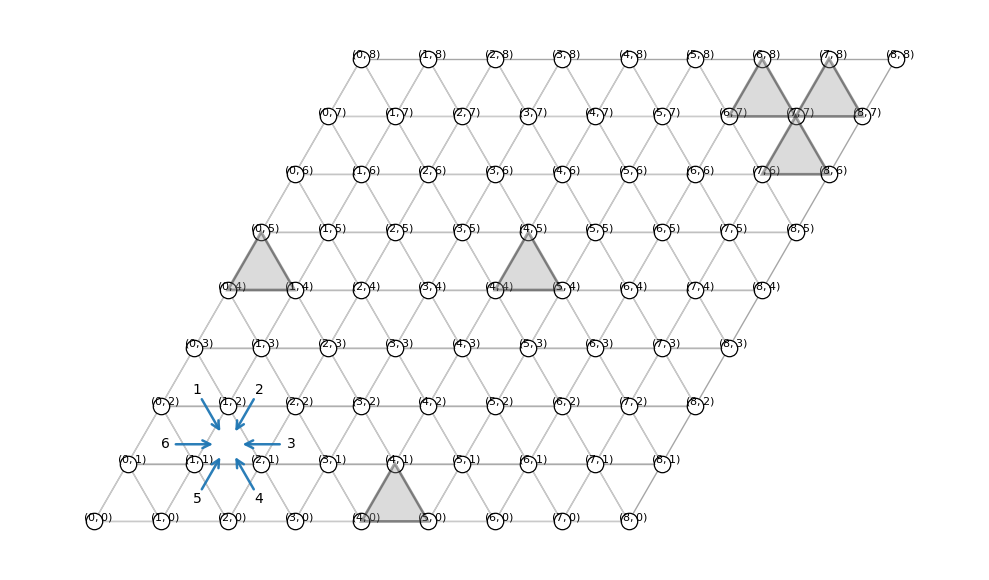

In [111]:
# ------------------------------------------------------------
# Example
# ------------------------------------------------------------
Lx, Ly = 9, 9

triangle_vals_dict = {
    # (2, 2): 1,
    # (3, 3): 1,
    # (4, 2): 1,
    # (3, 1): 1,
    # (2, 3): 1,
    # (4, 1): 1,
    # (5, 0): 2,
    # (3, 0): 2,
    # (1, 4): 2,
    # (1, 2): 2,
    # (5, 2): 2,
    # (3, 4): 2,
    # (0, 2): 3,
    # (6, 2): 3, 
    # (0, 5): 3, 
    # (3, 5): 3

}


focus_check = (1, 1)

fig, ax = draw_nm_lattice(
    Lx=Lx,
    Ly=Ly,
    triangle_values=triangle_vals_dict,
    highlight_checks=violated_checks,
    shade_all_value_triangles=False,
    show_all_check_outlines=True,
    show_spin_labels=error_qubits,
    value_format=".2f",
    draw_direction_arrows=True,
    arrow_checks={focus_check},
    arrow_dirs=(1, 2, 3, 4, 5, 6),
    # arrow_dirs=(),
    arrow_length_scale=0.82,
    label_arrow_dirs=True,
    figsize=(10, 7),
)

plt.show()

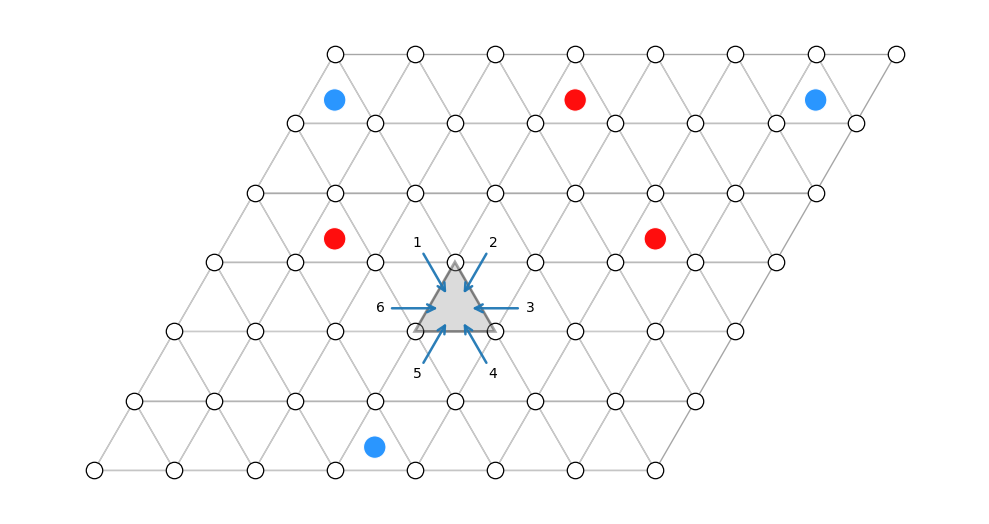

In [16]:
focus_check = (3, 2)

triangle_center_circles = {
    (0, 5): "dodgerblue",
    (3, 5): "red",
    (6, 5): "dodgerblue",
    (1, 3): "red",
    (5, 3): "red",
    (3, 0): "dodgerblue",
}

fig, ax = draw_nm_lattice(
    Lx=8,
    Ly=7,
    triangle_values={},
    highlight_checks={focus_check},
    draw_direction_arrows=True,
    arrow_checks={focus_check},
    triangle_center_circles=triangle_center_circles,
    circle_radius=0.14,
    figsize=(10, 7),
)

plt.show()